In [1]:
import pandas as pd

df = pd.read_csv("cleaned_financial_dataset.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (3440, 6)


,text,sentiment,text_length,cleaned_text,sentiment_encoded,cleaned_length
0,"According to Gran , the company has no plans t...",neutral,127,according gran company no plan move production...,1,78
1,With the new production plant the company woul...,positive,206,new production plant company would increase ca...,2,157
2,"For the last quarter of 2010 , Componenta 's n...",positive,193,last quarter 2010 componenta net sale doubled ...,2,123
3,"In the third quarter of 2010 , net sales incre...",positive,125,third quarter 2010 net sale increased 52 % eur...,2,88
4,Operating profit rose to EUR 13.1 mn from EUR ...,positive,122,operating profit rose eur 131 mn eur 87 mn cor...,2,95


In [13]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_encoder.fit(df["sentiment"])

print("Classes:", label_encoder.classes_)

Classes: ['negative' 'neutral' 'positive']


In [2]:
from sklearn.model_selection import train_test_split

X = df["cleaned_text"]
y = df["sentiment_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Size:", X_train.shape)
print("Test Size:", X_test.shape)

Train Size: (2752,)
Test Size: (688,)


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF Shape:", X_train_tfidf.shape)

TF-IDF Shape: (2752, 10000)


In [4]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train_tfidf, y_train)

log_pred = log_model.predict(X_test_tfidf)

In [5]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(class_weight="balanced")
svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

In [6]:
from sklearn.metrics import classification_report, accuracy_score

print("🔹 Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

print("\n🔹 SVM Results")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

🔹 Logistic Regression Results
Accuracy: 0.8023255813953488
              precision    recall  f1-score   support

           0       0.74      0.60      0.66        84
           1       0.84      0.90      0.87       427
           2       0.72      0.67      0.69       177

    accuracy                           0.80       688
   macro avg       0.76      0.72      0.74       688
weighted avg       0.80      0.80      0.80       688


🔹 SVM Results
Accuracy: 0.8066860465116279
              precision    recall  f1-score   support

           0       0.81      0.60      0.68        84
           1       0.84      0.91      0.87       427
           2       0.72      0.66      0.69       177

    accuracy                           0.81       688
   macro avg       0.79      0.72      0.75       688
weighted avg       0.80      0.81      0.80       688



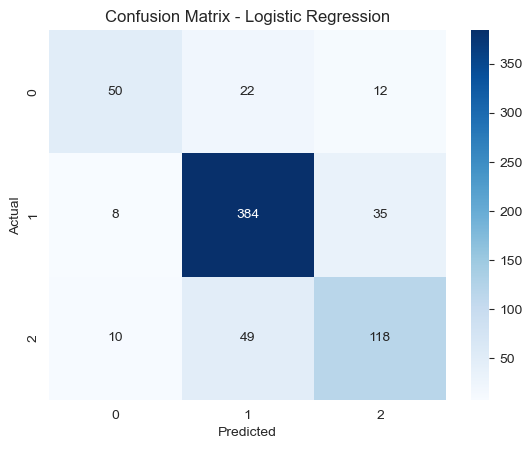

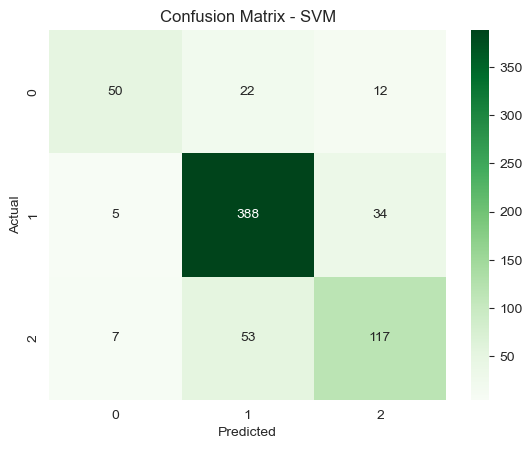

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_style("whitegrid")

# Logistic Regression
cm_log = confusion_matrix(y_test, log_pred)

plt.figure()
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM
cm_svm = confusion_matrix(y_test, svm_pred)

plt.figure()
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Greens")
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

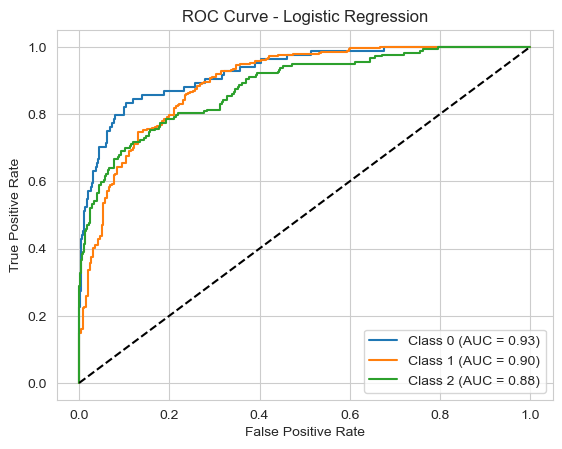

In [8]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np

# Binarize labels
classes = np.unique(y)
y_test_bin = label_binarize(y_test, classes=classes)

# Logistic Regression probabilities
log_probs = log_model.predict_proba(X_test_tfidf)

plt.figure()

for i in range(len(classes)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], log_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

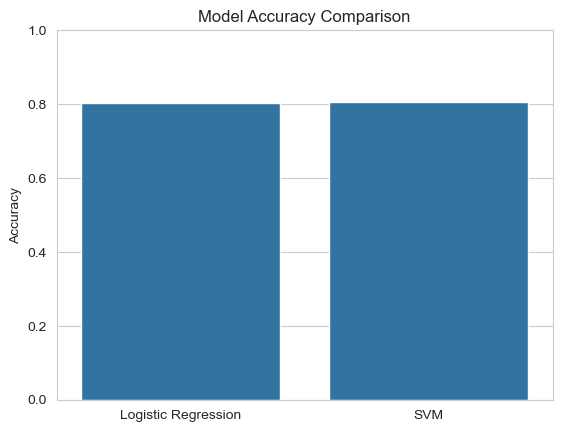

In [11]:
log_acc = accuracy_score(y_test, log_pred)
svm_acc = accuracy_score(y_test, svm_pred)

plt.figure()
sns.barplot(x=["Logistic Regression", "SVM"], y=[log_acc, svm_acc])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()

In [14]:
import pickle

with open("financial_model.pkl", "wb") as f:
    pickle.dump(log_model, f)

with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(tfidf, f)

with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("All files saved successfully.")

All files saved successfully.
